### **3.4 Time Series Naive Prediction**

In this activity, you will apply everything you have learned this week. You will prepare a dataset for time series forecasting, create baseline and naive forecasting models, and determine whether the time series behaves like a random walk. If it does, you will implement a forecasting approach appropriate for a random walk.

We will continue working with a **univariate time series dataset**.

The dataset used in this activity is the **Air Passengers dataset** - originally available as a default dataset in R. This dataset provides monthly totals of a US airline passengers from 1949 to 1960.

This activity has been adapted from [Preparing data for time series analysis](https://medium.com/data-science/preparing-data-for-time-series-analysis-cd6f080e6836)

**Importing Required Libraries**

We will begin by importing the necessary Python libraries for working with time series data.

- `pandas` and `numpy` are used for data manipulation.
- `matplotlib` is used for plotting.
- `statsmodels` provides tools for time series decomposition, autocorrelation plots, and stationarity testing.
- We also suppress warnings to keep the notebook output clean.

The `%matplotlib inline` command ensures that plots are displayed within the notebook.

In [27]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf

# Data manipulation
import pandas as pd
import numpy as np

# Machine learning tools from the scikit-learn library
from sklearn.metrics import mean_squared_error

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

**Load the Dataset**

In [2]:
# Read the CSV file containing the Air Passengers data into a DataFrame
df_air = pd.read_csv('./data/AirPassengers.csv', parse_dates=['Month'], index_col='Month')

In [3]:
# Display the first few rows of the DataFrame to verify that the data has been loaded correctly
df_air.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
# Rename the #Passengers to numPassengers
df_air.rename(columns={'#Passengers': 'numPassengers'}, inplace=True)

In [5]:
# Check the data types of the columns in the DataFrame
df_air.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   numPassengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


**Is the series a random walk?**

To determine if the time series is a random walk, we apply the Augmented Dickey-Fuller (ADF) test.
- **Null hypotheses ($H_{0}$)**: The series has a unit root (i.e. it is a random walk).
- **Alternative hypothesis ($H_{1}$)**: The series is stationary.

If the p-value is greater than 0.05, we fail to reject the null hypothesis and the series mau be a random walk. If the p-value is 0.05 or less, we reject the null hypothesis and conclude the series is likely **not** a random walk.

In [6]:
# Apply the Augmented Dickey-Fuller test to check for stationarity
result = adfuller(df_air['numPassengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

if result[1] < 0.05:
    print("Reject the null hypothesis. The time series may be stationary and is not likely a random walk.")
else:
    print("Fail to reject the null hypothesis. The time series is likely not stationary and may be a random walk.")

ADF Statistic: 0.815368879206063
p-value: 0.9918802434376413
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
Fail to reject the null hypothesis. The time series is likely not stationary and may be a random walk.


**Testing Stationarity of the First Difference**

We apply the Augmented Dickey-Fuller (ADF) test to the **first difference** of the series. This helps us check whether removing the trend has made the series stationary.

- If the p-value is $\le0.05$, we reject the null hypothesis and conclude the differenced series is **stationary**.

- If the p-value is $\gt0.05$, the first difference may still be non-stationary.

This step is important before fitting models like ARIMA, which require a stationary input.

In [7]:
#Calculate the first difference of the time series to make it stationary
diff_1 = df_air['numPassengers'].diff().dropna()

adf_result_diff_1 = adfuller(diff_1)
print('ADF Statistic (1st Difference):', adf_result_diff_1[0])
print('p-value (1st Difference):', adf_result_diff_1[1])
print('Critical Values (1st Difference):', adf_result_diff_1[4])

if adf_result_diff_1[1] < 0.05:
    print("Reject the null hypothesis. The first-differenced time series may be stationary and is not likely a random walk.")
else:
    print("Fail to reject the null hypothesis. The first-differenced time series is likely not stationary and may be a random walk.")

ADF Statistic (1st Difference): -2.829266824170006
p-value (1st Difference): 0.05421329028382468
Critical Values (1st Difference): {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
Fail to reject the null hypothesis. The first-differenced time series is likely not stationary and may be a random walk.


The Augmented Dickey-Fuller test on the first-differenced series returns a p-value of **0.0542**.

Since this is **slightly above 0.05**, we **fail to reject the null hypothesis** at the 5% significance level. This suggests that the first difference may still be non-stationary.

<span style="color:red;font-weight:bold">Warning</span>: The result is borderline. While it does not strongly support stationarity, it is close enough that further inspection (such as plotting the differenced series or testing model residuals) is recommended before deciding on further differencing or transformations.

We plot the ACF of the **first-differenced series** to further assess whether the original time series behaves like a random walk.

*If the original series were a pure random walk, the first difference would resemble white noise, showing **no significant autocorrelation** at any lag.*

<Figure size 1000x500 with 0 Axes>

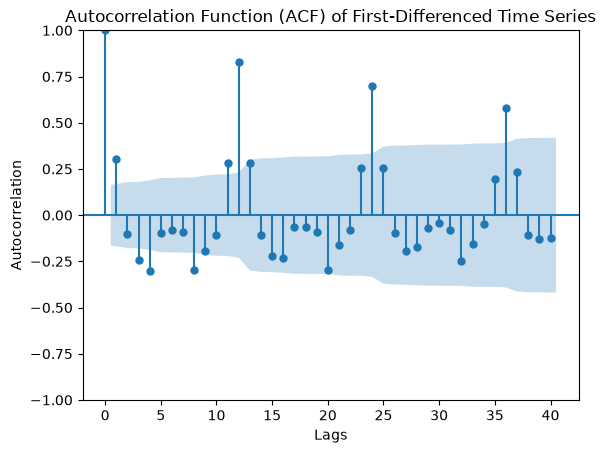

In [8]:
# Plot ACF of the first-differenced time series
plt.figure(figsize=(10, 5))
plot_acf(diff_1, lags=40)
plt.title('Autocorrelation Function (ACF) of First-Differenced Time Series')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

The plot of the first-differenced series shows several significant spikes, indicating that the series is **not a pure random walk** and retains **autocorrelation structure**.

**Distribution of Passenger Counts**

Examine the distribution of monthly passenger counts using a histogram.

**Note**: This does **not** show how passenger numbers change over time - it only shows how often certain values occur across the dataset.

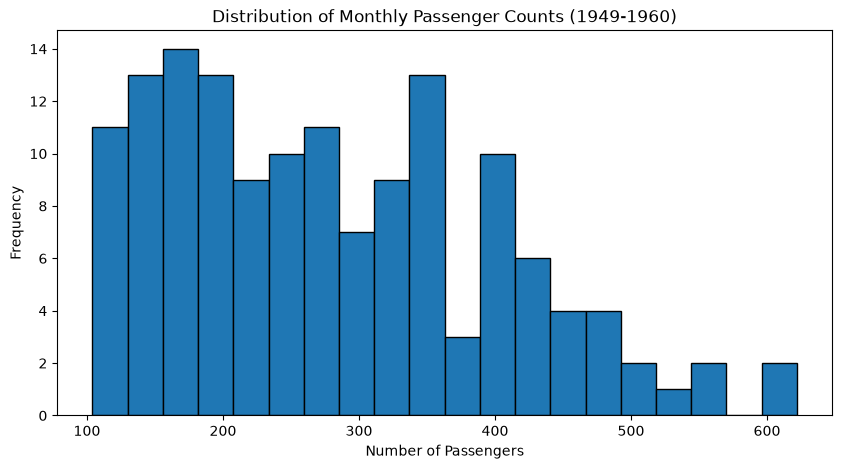

In [9]:
# Plot the distribution of monthly passenger counts to visualize the data
plt.figure(figsize=(10, 5))
plt.hist(df_air['numPassengers'], bins=20, edgecolor='k')
plt.title('Distribution of Monthly Passenger Counts (1949-1960)')
plt.xlabel('Number of Passengers')
plt.ylabel('Frequency')
plt.show()

The histogram shows that most monthly passenger counts fall between 100 and 300, with fewer months having very high values (above 500). This results in a **right-skewed distribution**, where lower values are more common.

While the histogram doesn't reveal time-based patterns, it still provides some useful insights:

- The wide spread of values may suggest that **variance changes over time**, but since a histogram ignores the time dimension, this must be verified with a time plot or statistical test.

<span style="color:red;font-weight:bold">!!</span> **Note**: A **normal distribution is not required** for time series forecasting. However, inspecting the distribution can help identify potential issues - such as **non-constant variance** - that may affect model performance or violate assumptions of certain methods (e.g. ARIMA residuals).

** Time Series Plot**

Now that we have looked at the distribution of values, let's plot the actual time series to observe how the number of airline passengers changes over time.

The plot will help us visually assess trends, seasonality, or other temporal patterns in the data.

<Axes: title={'center': 'Monthly Air Passengers (1949-1960)'}, xlabel='Year', ylabel='Number of Passengers'>

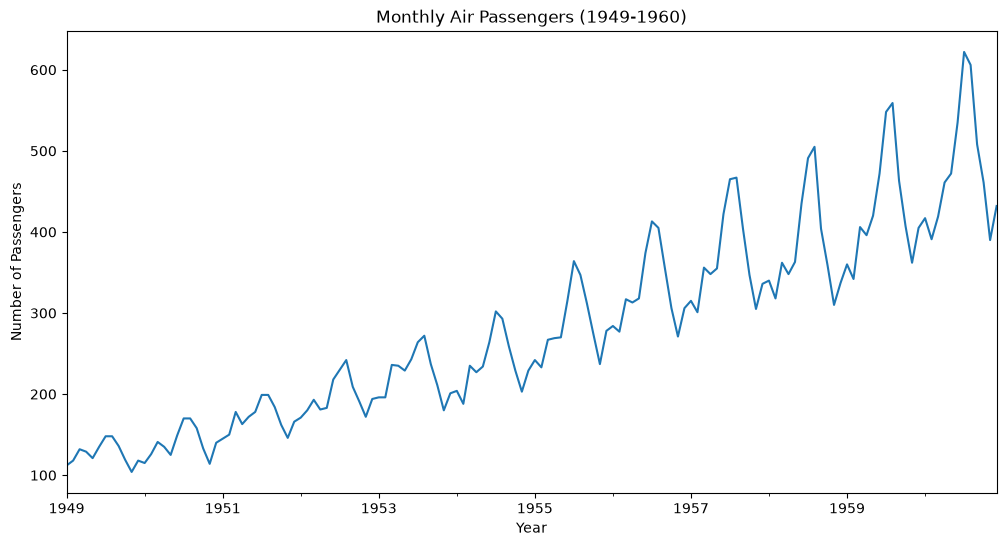

In [10]:
# Plot the original time series
df_air.plot(figsize=(12, 6), y='numPassengers', title='Monthly Air Passengers (1949-1960)', legend=False, ylabel='Number of Passengers', xlabel='Year')

Key observations:

- There is a clear **upward trend**, indicating that passenger numbers increased over time.

- A **repeating seasonal pattern** is visable, with regular peaks and troughs occurring each year.

- The **magnitude of fluctuations increases over time**, suggesting **non-constant variance**.

These features indicate that the series is likely **non-stationary**, both in mean and variance. This should be addressed before applying models that assume stationarity, such as ARIMA.

**Data Transformation**

We apply a **log transformation** to stabilise the variance in the time series. This is particularly helpful when the range of values increases over time, as it reduces the impact of larger values and can make the series more suitable for modelling.

Log transformation is a common choice for data that shows **multiplicative seasonality or increasing variance**.

<span style="color:cyan;font-weight:bold">**</span> An alternative to the log transformation is the **Box-Cox transformation**, which automatically finds a suitable power transformation for the data. However, log transformation is often sufficient and more interpretable for many practical purposes.

Note: This transformation is applied before differencing or decomposition steps and does **not** require the data to be normally distributed.

In [11]:
# Apply a log transformation to stabilize the variance
df_air_log = np.log(df_air)

# Preview the log-transformed data
df_air_log.head()

,numPassengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791


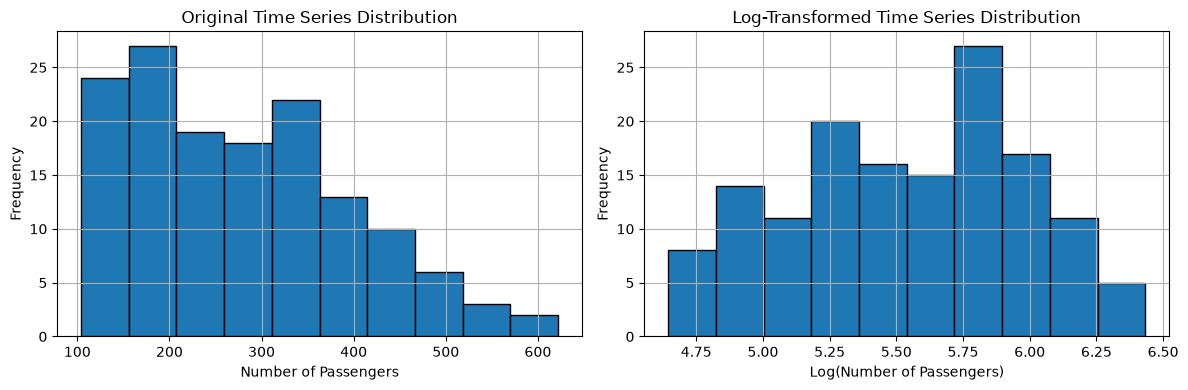

In [12]:
# Plot side-by-side the original and log-transformed time series for comparison
fig,ax = plt.subplots(1,2,figsize=(12,4))

# Plot histogram of the original time series
df_air.hist(ax=ax[0], edgecolor='k')
ax[0].set_title('Original Time Series Distribution')
ax[0].set_xlabel('Number of Passengers')
ax[0].set_ylabel('Frequency')

# Plot histogram of the log-transformed time series
df_air_log.hist(ax=ax[1], edgecolor='k')
ax[1].set_title('Log-Transformed Time Series Distribution')
ax[1].set_xlabel('Log(Number of Passengers)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The log transformation has reduced the right skew of the original distribution, making the values more symmetric and compressing the higher range of passenger counts.

This helps stabilise variance and prepares the data for time series modelling techniques that assume more consistent scale over time.

**STL Decomposition of Log-Transformed Series**

We apply STL (Seasonal-Trend decomposition using Loess) to the **log-transformed** data. This method separates the series into trend, seasonal, and residual components.

- We set `period=12` to reflect the monthly seasonality (12 months per cycle).

- `robust=True` helps reduce the impact of outliers on the trend and seasonal components.

STL is a flexible and preferred method for decomposition, especially when the seasonal pattern or variance changes over time.

<span style="color:orange;font-weight:bold">**</span> **Note: Decomposing the Original Data**

Decomposing the raw time series can be useful for quick visual exploration of trend and seasonality - but only if the variance is relatively stable.

If the data shows **multiplicative seasonality** (i.e. increasing seasonal variation over time), it is better to apply a **log transformation first**. This stabilises variance and results in clearer, more reliable decomposition for analysis and forecasting.

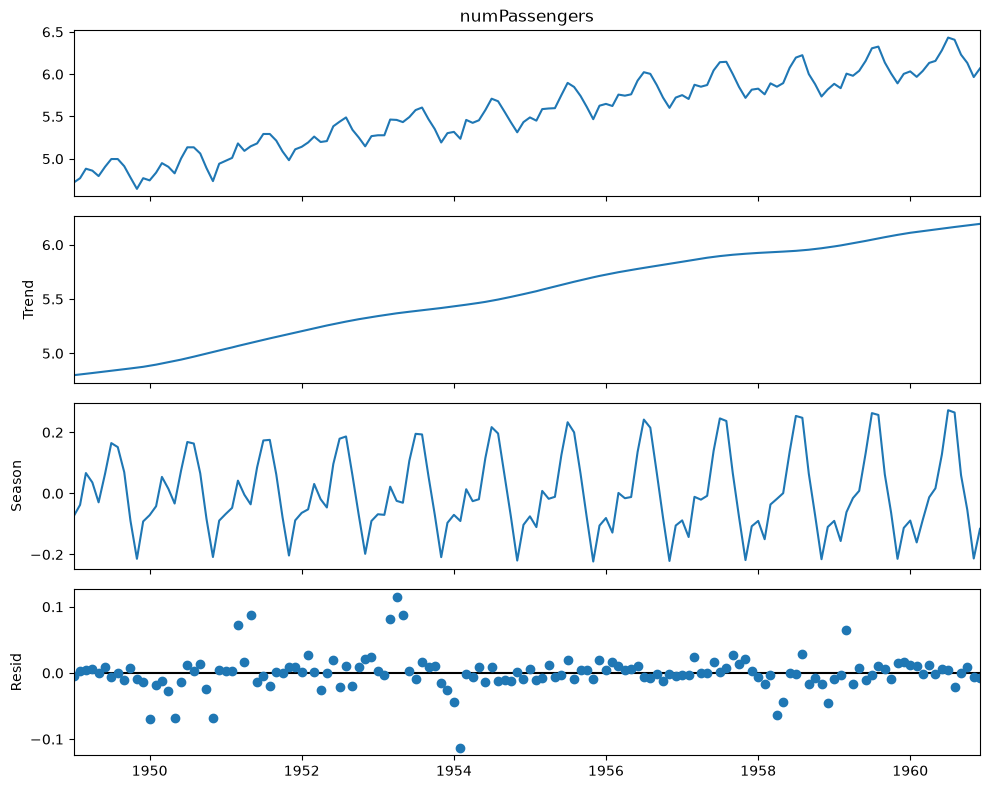

In [13]:
# Perform STL decomposition on the log-transformed time series to separate trend, seasonality, and residuals
# period=12 is used for monthly data with yearly seasonality
# robust=True is used to make the decomposition less sensitive to outliers
stl_result = STL(df_air_log["numPassengers"], period=12, robust=True).fit()

# Plot the STL decomposition results
fig = stl_result.plot()
fig.set_size_inches(10, 8)
fig.tight_layout()
plt.show()

The STL decomposition of the log-transformed series shows the following:

- **Trend**: A clear upward movement over time, indicating long-term growth in passenger numbers.

- **Seasonal**: A repeating yearly pattern that remains consistent after the log transformation - this confirms strong seasonality in the data.

- **Residual**: Mostly centred around zero, suggesting that the trend and seasonality have been well captured. However, a few larger residuals appear in certain periods (e.g. 1952-1954), indicating some unexplained variation remains.

**Naive Forecasting: Historical Mean**

We reserve the final year of data (12 months) as a test set and compute the **historical mean** from the training period.

The naive forecast uses the same constant value (the mean of the training data) for all future time points. It serves as a basic benchmark to compare more sophisticated forecasting models.

In [14]:
# Split the log-transformed time series into training and testing sets
train = df_air_log.iloc[:-12]  # Use all but the last 12 months for training
test = df_air_log.iloc[-12:]   # Use the last 12 months for testing

# Calculate historical mean from the training set
historical_mean = train['numPassengers'].mean()

# Assign forecast values to a new column only for the test period
df_air_log["historical_mean"] = np.nan  # Initialize the column with NaN values
df_air_log.loc[test.index, "historical_mean"] = historical_mean  # Assign the historical mean to the test period

df_air_log.tail()

,numPassengers,historical_mean
Month,,
1960-08-01,6.406880,5.486536
1960-09-01,6.230481,5.486536
1960-10-01,6.133398,5.486536
1960-11-01,5.966147,5.486536
1960-12-01,6.068426,5.486536


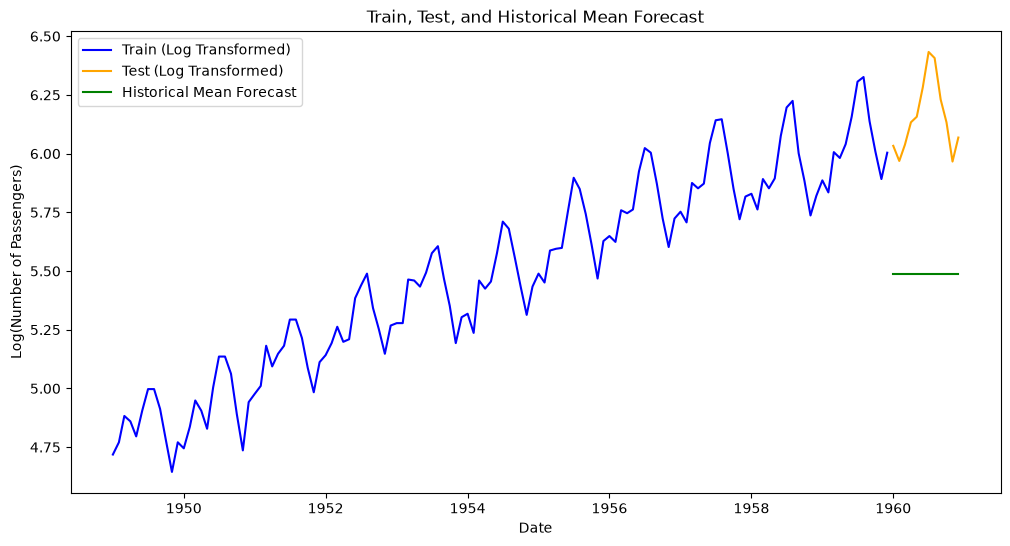

In [15]:
# Plot train, test, and forecast with 3 distinct colours
plt.figure(figsize=(12, 6))

# Plot train data
plt.plot(train.index, train['numPassengers'], label='Train (Log Transformed)', color='blue')

# Plot test data
plt.plot(test.index, test['numPassengers'], label='Test (Log Transformed)', color='orange')

# Plot historical mean forecast
plt.plot(test.index, df_air_log.loc[test.index, "historical_mean"], label='Historical Mean Forecast', color='green')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Log(Number of Passengers)')
plt.title('Train, Test, and Historical Mean Forecast')
plt.legend()
plt.show()

**Forecast using previous year's mean**

In [16]:
# Get the last full year in the training set (1959)
last_full_year = train.loc['1959-01-01':'1959-12-01']
last_year_mean = last_full_year['numPassengers'].mean()

# Assign the last year's mean to the forecast column for the test period
df_air_log["last_year_mean"] = np.nan  # Initialize the column with NaN
df_air_log.loc[test.index, "last_year_mean"] = last_year_mean  # Assign the last year's mean to the test period

df_air_log.tail()

,numPassengers,historical_mean,last_year_mean
Month,,,
1960-08-01,6.406880,5.486536,6.048368
1960-09-01,6.230481,5.486536,6.048368
1960-10-01,6.133398,5.486536,6.048368
1960-11-01,5.966147,5.486536,6.048368
1960-12-01,6.068426,5.486536,6.048368


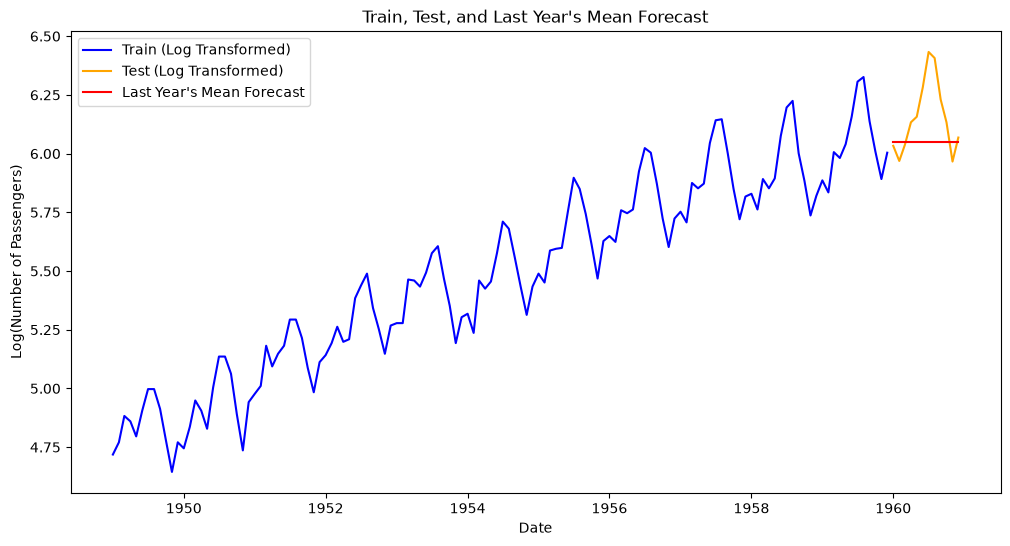

In [17]:
# Plot train, test, and forecast (using previous year's mean) with 3 distinct colours
plt.figure(figsize=(12, 6))

# Plot train data
plt.plot(train.index, train['numPassengers'], label='Train (Log Transformed)', color='blue')

# Plot test data
plt.plot(test.index, test['numPassengers'], label='Test (Log Transformed)', color='orange')

# Plot historical mean forecast
# plt.plot(test.index, df_air_log.loc[test.index, "historical_mean"], label='Historical Mean Forecast', color='green')

# Plot last year's mean forecast
plt.plot(test.index, df_air_log.loc[test.index, "last_year_mean"], label="Last Year's Mean Forecast", color='red')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Log(Number of Passengers)')
plt.title('Train, Test, and Last Year\'s Mean Forecast')
plt.legend()
plt.show()

**Forecast using the last known value**

In [18]:
# Get the last known value from the training set to use as the forecast for the first month of the test set
last_known_value = train['numPassengers'].iloc[-1]

# Forecast: repeat the last known value for each point in the test set
df_air_log["last_known_value_forecast"] = np.nan  # Initialize the column with NaN values
df_air_log.loc[test.index, "last_known_value_forecast"] = last_known_value  # Assign the last known value to the test period
df_air_log.tail()

,numPassengers,historical_mean,last_year_mean,last_known_value_forecast
Month,,,,
1960-08-01,6.406880,5.486536,6.048368,6.003887
1960-09-01,6.230481,5.486536,6.048368,6.003887
1960-10-01,6.133398,5.486536,6.048368,6.003887
1960-11-01,5.966147,5.486536,6.048368,6.003887
1960-12-01,6.068426,5.486536,6.048368,6.003887


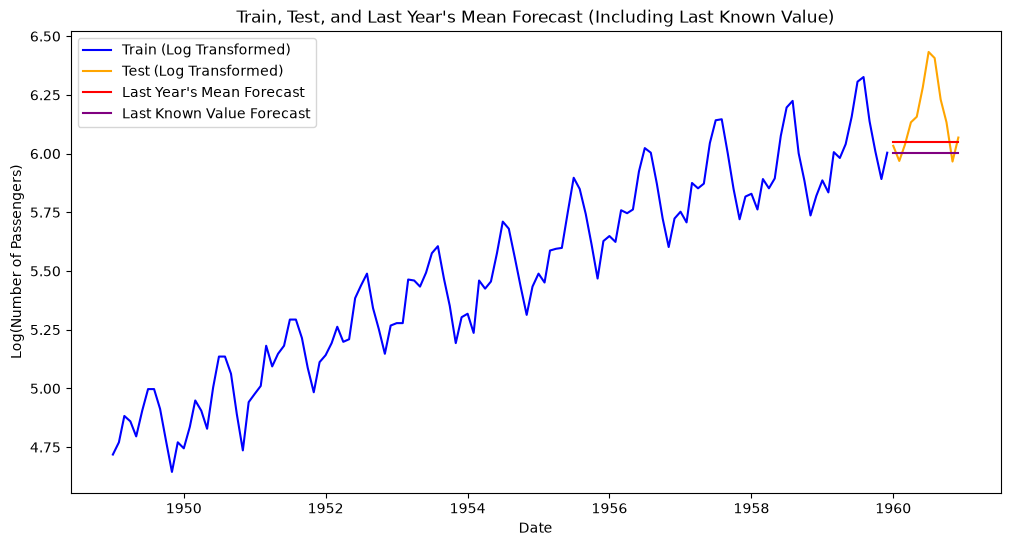

In [19]:
# Plot train, test, and forecast (using last known value) with 3 distinct colours
plt.figure(figsize=(12, 6))

# Plot train data
plt.plot(train.index, train['numPassengers'], label='Train (Log Transformed)', color='blue')

# Plot test data
plt.plot(test.index, test['numPassengers'], label='Test (Log Transformed)', color='orange')

# Plot historical mean forecast
# plt.plot(test.index, df_air_log.loc[test.index, "historical_mean"], label='Historical Mean Forecast', color='green')

# Plot last year's mean forecast
plt.plot(test.index, df_air_log.loc[test.index, "last_year_mean"], label="Last Year's Mean Forecast", color='red')
plt.plot(test.index, df_air_log.loc[test.index, "last_known_value_forecast"], label="Last Known Value Forecast", color='purple')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Log(Number of Passengers)')
plt.title('Train, Test, and Last Year\'s Mean Forecast (Including Last Known Value)')
plt.legend()
plt.show()

**Naive Season Forecast**

Is the data seasonal? Look at the graph you produce when you decomposed the time series data. Using the last known value does not take the seasonality into account, se we need to use another naive forecasting technique to see if we can produce a better baseline.

In [20]:
# Reuse values from the last full year (1959) to forecast the next year (1960)
df_air_log["seasonal_naive"] = np.nan  # Initialize the column with NaN values
# Assign the values from the last full year to the forecast for the test period
df_air_log.loc[test.index, "seasonal_naive"] = df_air_log.loc[train.index[-12:], "numPassengers"].values

df_air_log.tail()

,numPassengers,historical_mean,last_year_mean,last_known_value_forecast,seasonal_naive
Month,,,,,
1960-08-01,6.406880,5.486536,6.048368,6.003887,6.326149
1960-09-01,6.230481,5.486536,6.048368,6.003887,6.137727
1960-10-01,6.133398,5.486536,6.048368,6.003887,6.008813
1960-11-01,5.966147,5.486536,6.048368,6.003887,5.891644
1960-12-01,6.068426,5.486536,6.048368,6.003887,6.003887


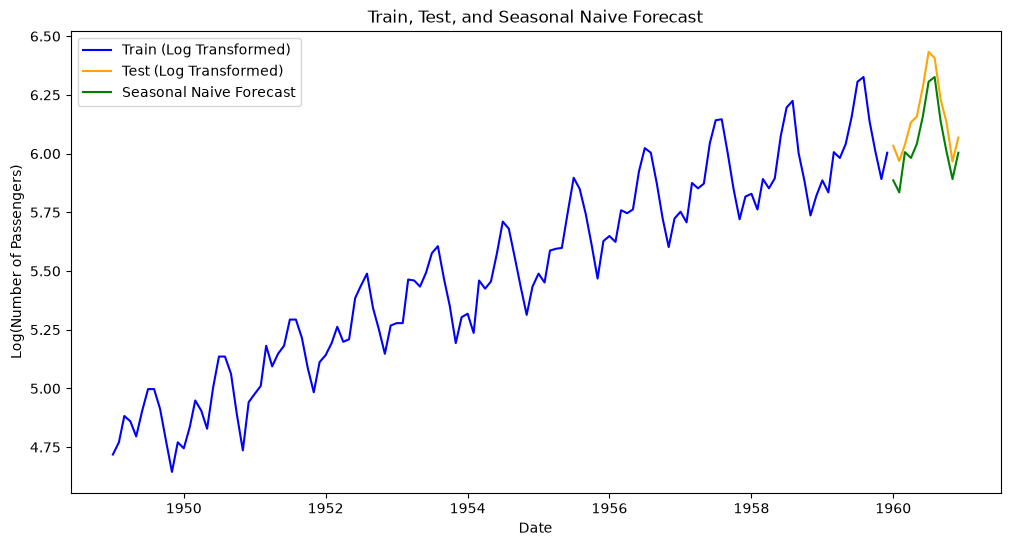

In [21]:
# Plot train, test, and seasonal naive forecast with 3 distinct colours
plt.figure(figsize=(12, 6))

# Plot train data
plt.plot(train.index, train['numPassengers'], label='Train (Log Transformed)', color='blue')

# Plot test data
plt.plot(test.index, test['numPassengers'], label='Test (Log Transformed)', color='orange')

# Plot seasonal naive forecast
plt.plot(test.index, df_air_log.loc[test.index, "seasonal_naive"], label='Seasonal Naive Forecast', color='green')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Log(Number of Passengers)')
plt.title('Train, Test, and Seasonal Naive Forecast')
plt.legend()
plt.show()

**Drift Forecast**

The drift method is a simple extension of the naive (last value) approach. Instead of predicting a constant value, it allows the forecast to **increase or decrease over time** at a steady rate. This rate is based on the **average change observed in the training data** - specifically, it is the slope between the **first and last values** in the training set.

We use this slope to extend a straight line into the future, effectively **extrapolating** the trend seen in the training data.

The formula for the drift forecast is:

$$\hat{y}_{t+h}=y_{t}+\frac{y_{t}-y_{1}}{t-1}\cdot h$$

Where:

- $y_{t}$ is the last value in the training set
- $y_{1}$ is the first value in the training set
- $t$ is the number of time points in the training set
- $h$ is the forecast horizon (e.g. 1, 2, ..., 12)

In [22]:
# Get start and end of training data
y_first = train["numPassengers"].iloc[0]
y_last = train["numPassengers"].iloc[-1]
n = len(train)

# Forecast horizon
h = np.arange(1, len(test) + 1)  # Forecast horizon for the test set (12 months)

# Drift forecast formula
drift_forecast_values = y_last + (y_last - y_first) / (n - 1) * h

# Assign to the dataframe
df_air_log["drift_forecast"] = np.nan  # Initialize the column with NaN values
df_air_log.loc[test.index, "drift_forecast"] = drift_forecast_values

df_air_log.tail()

,numPassengers,historical_mean,last_year_mean,last_known_value_forecast,seasonal_naive,drift_forecast
Month,,,,,,
1960-08-01,6.406880,5.486536,6.048368,6.003887,6.326149,6.082384
1960-09-01,6.230481,5.486536,6.048368,6.003887,6.137727,6.092196
1960-10-01,6.133398,5.486536,6.048368,6.003887,6.008813,6.102008
1960-11-01,5.966147,5.486536,6.048368,6.003887,5.891644,6.111820
1960-12-01,6.068426,5.486536,6.048368,6.003887,6.003887,6.121633


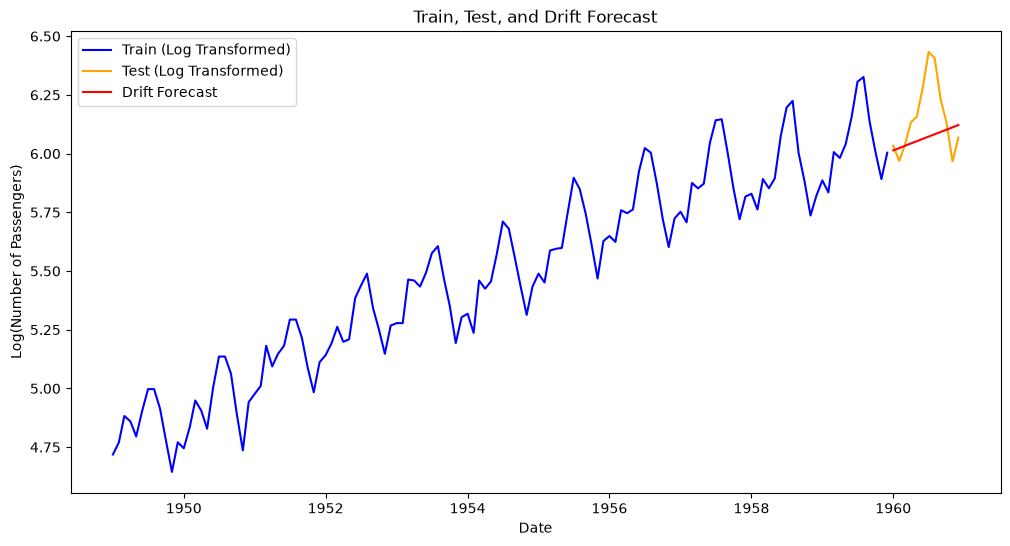

In [23]:
# Plot train, test, and drift forecast with 3 distinct colours
plt.figure(figsize=(12, 6))

# Plot train data
plt.plot(train['numPassengers'], label='Train (Log Transformed)', color='blue')

# Plot test data
plt.plot(test['numPassengers'], label='Test (Log Transformed)', color='orange')

# Plot drift forecast
plt.plot(df_air_log["drift_forecast"], label='Drift Forecast', color='red')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Log(Number of Passengers)')
plt.title('Train, Test, and Drift Forecast')
plt.legend()
plt.show()

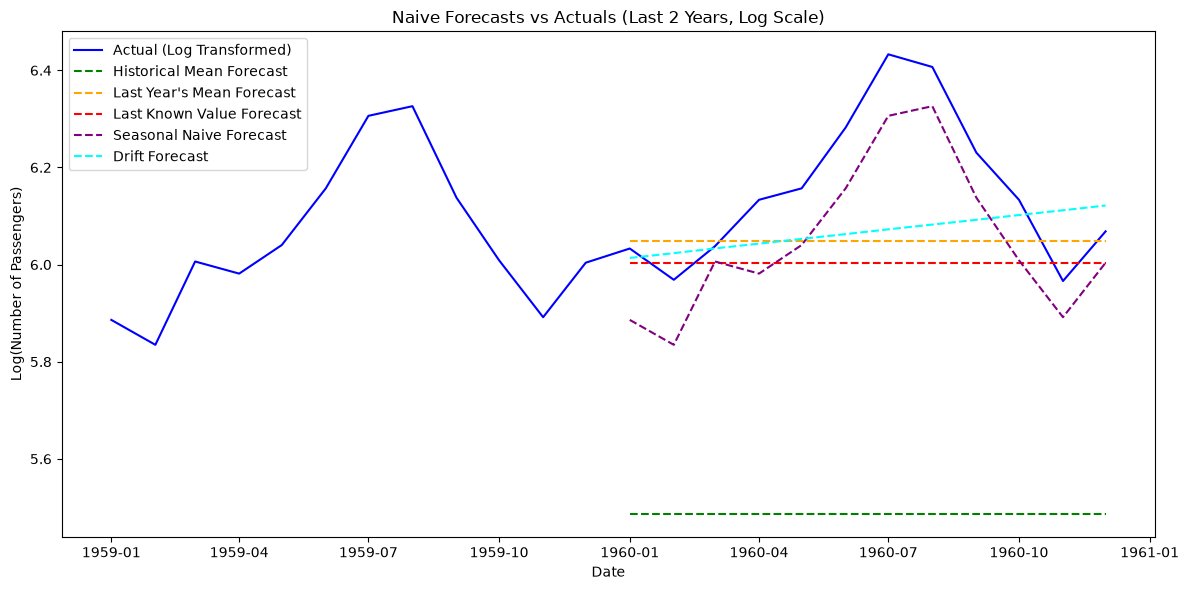

In [25]:
# Select the last 24 months from the full dataset
last_2_years = df_air_log.iloc[-24:]

plt.figure(figsize=(12, 6))

# Actual values
plt.plot(last_2_years.index, last_2_years['numPassengers'], label='Actual (Log Transformed)', color='blue')

# Forecasts (plotted only for test period, but shown in last 2 years view)
plt.plot(test.index, df_air_log.loc[test.index, "historical_mean"], label='Historical Mean Forecast', linestyle='--', color='green')

plt.plot(test.index, df_air_log.loc[test.index, "last_year_mean"], label="Last Year's Mean Forecast", linestyle='--', color='orange')

plt.plot(test.index, df_air_log.loc[test.index, "last_known_value_forecast"], label="Last Known Value Forecast", linestyle='--', color='red')

plt.plot(test.index, df_air_log.loc[test.index, "seasonal_naive"], label='Seasonal Naive Forecast', linestyle='--', color='purple')

plt.plot(test.index, df_air_log.loc[test.index, "drift_forecast"], label='Drift Forecast', linestyle='--', color='cyan')

# Plot settings
plt.xlabel('Date')
plt.ylabel('Log(Number of Passengers)')
plt.title('Naive Forecasts vs Actuals (Last 2 Years, Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()

**Beginner-Friendly Code to Calculate Mean Squared Error (log scale**)

<span style="color:orange;font-weight:bold">**</span> **Note:** Because both actual and forecasted values are in **log scale**, it is valid to calculate MSE without inverting them.

However, MSE in log space measures squared error in the **log of the values**, not the original units. This useful for comparing models fairly on a transformed scale, but should not be interpreted as real-world forecasting accuracy.

For real-world interpretability, consider evaluating errors in the original scale as well.

In [28]:
# Actual values from the test set (log-transformed)
actual = test['numPassengers']

# Forecasts
historical_mean = df_air_log.loc[test.index, "historical_mean"]
last_year_mean = df_air_log.loc[test.index, "last_year_mean"]
last_value = df_air_log.loc[test.index, "last_known_value_forecast"]
seasonal_naive = df_air_log.loc[test.index, "seasonal_naive"]
drift_forecast = df_air_log.loc[test.index, "drift_forecast"]

# Calculate MSE for each forecast method
mse_historical_mean = mean_squared_error(actual, historical_mean)
mse_last_year_mean = mean_squared_error(actual, last_year_mean)
mse_last_value = mean_squared_error(actual, last_value)
mse_seasonal_naive = mean_squared_error(actual, seasonal_naive)
mse_drift_forecast = mean_squared_error(actual, drift_forecast)

# Print the MSE results
print(f'MSE - Historical Mean Forecast: {mse_historical_mean:.4f}')
print(f'MSE - Last Year Mean Forecast: {mse_last_year_mean:.4f}')
print(f'MSE - Last Value Forecast: {mse_last_value:.4f}')
print(f'MSE - Seasonal Naive Forecast: {mse_seasonal_naive:.4f}')
print(f'MSE - Drift Forecast: {mse_drift_forecast:.4f}')

MSE - Historical Mean Forecast: 0.4683
MSE - Last Year Mean Forecast: 0.0337
MSE - Last Value Forecast: 0.0451
MSE - Seasonal Naive Forecast: 0.0124
MSE - Drift Forecast: 0.0292


**Optimised Version (Uses a Dictionary + Loop)**

Now that you have seen the step-by-step MSE calculation, here is a more efficient version. It uses a dictionary to map method names to their forecast columns and calculates all MSE values in a compact loop.

This approach makes the code easier to maintain and extend, especially when working with multiple models.

In [29]:
# Define forecast columns to evaluate
methods = {
    'Historical Mean': "historical_mean",
    'Last Year Mean': "last_year_mean",
    'Last Value': "last_known_value_forecast",
    'Seasonal Naive': "seasonal_naive",
    'Drift Forecast': "drift_forecast"
}

# Calculate MSEs in one step using a dictionary comprehension
mse_results = {
    name: mean_squared_error(test['numPassengers'], df_air_log.loc[test.index, col])
    for name, col in methods.items()
}

# Print the MSE results
for method, mse in mse_results.items():
    print(f'MSE - {method}: {mse:.4f}')

MSE - Historical Mean: 0.4683
MSE - Last Year Mean: 0.0337
MSE - Last Value: 0.0451
MSE - Seasonal Naive: 0.0124
MSE - Drift Forecast: 0.0292


Graphically compare the MSEs for these baselines

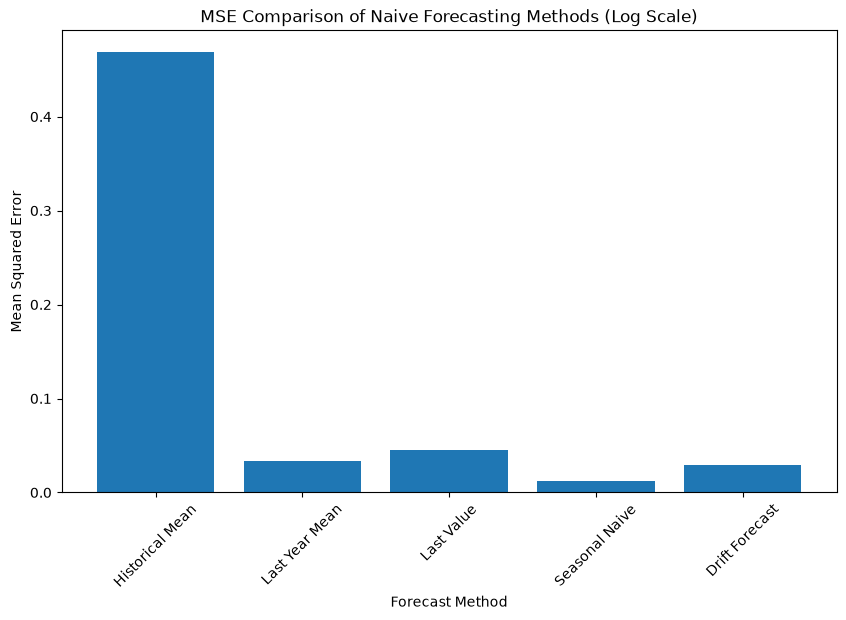

In [31]:
# Create bar chart to visualize MSE results
plt.figure(figsize=(10, 6))
plt.bar(mse_results.keys(), mse_results.values())
plt.xlabel('Forecast Method')
plt.ylabel('Mean Squared Error')
plt.title('MSE Comparison of Naive Forecasting Methods (Log Scale)')
plt.xticks(rotation=45)
plt.show()

**Forecasts in Original Scale**

We now reverse the log transformation using `np.exp()` to convert all data and forecasts back to the original passenger counts. This allows us to visualise the forecasts in real-world units and compare their performance more intuitively.



In [32]:
# Copy original data
df_air["historical_mean"] = np.exp(df_air_log["historical_mean"])
df_air["last_year_mean"] = np.exp(df_air_log["last_year_mean"])
df_air["last_known_value_forecast"] = np.exp(df_air_log["last_known_value_forecast"])
df_air["seasonal_naive"] = np.exp(df_air_log["seasonal_naive"])
df_air["drift_forecast"] = np.exp(df_air_log["drift_forecast"])

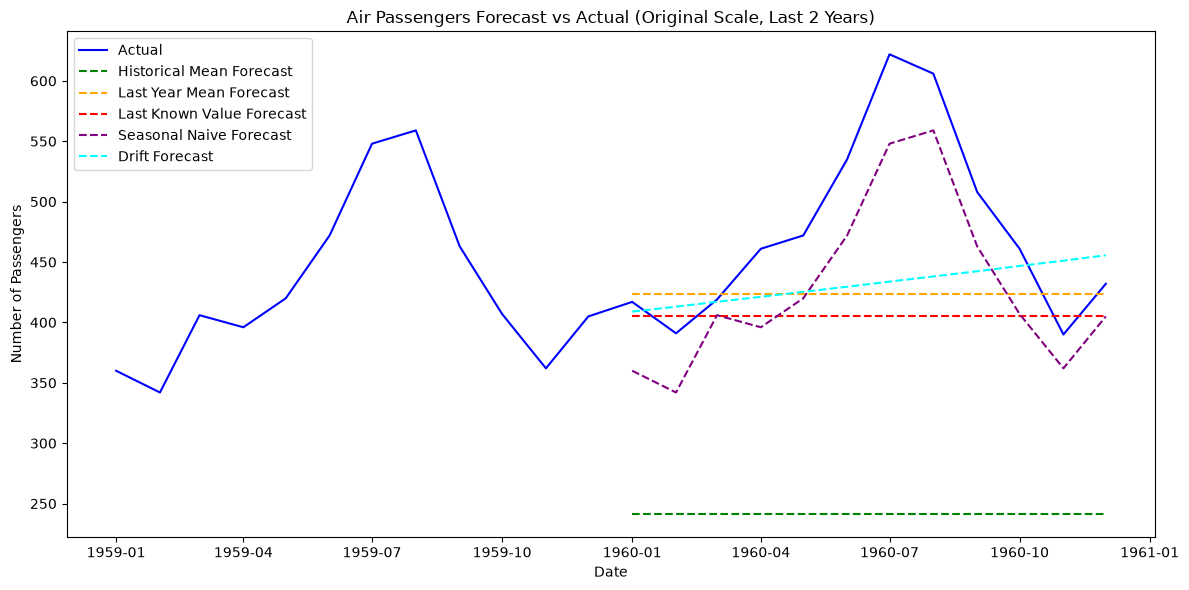

In [33]:
# Select last 2 years
last_2_years_original = df_air.iloc[-24:]

plt.figure(figsize=(12, 6))

# Actual values
plt.plot(last_2_years_original.index, last_2_years_original['numPassengers'], label='Actual', color='blue')

# Forecasts (plotted only for test period, but shown in last 2 years view)
plt.plot(test.index, df_air.loc[test.index, "historical_mean"], label='Historical Mean Forecast', linestyle='--', color='green')
plt.plot(test.index, df_air.loc[test.index, "last_year_mean"], label='Last Year Mean Forecast', linestyle='--', color='orange')
plt.plot(test.index, df_air.loc[test.index, "last_known_value_forecast"], label='Last Known Value Forecast', linestyle='--', color='red')
plt.plot(test.index, df_air.loc[test.index, "seasonal_naive"], label='Seasonal Naive Forecast', linestyle='--', color='purple')
plt.plot(test.index, df_air.loc[test.index, "drift_forecast"], label='Drift Forecast', linestyle='--', color='cyan')

# Plot settings
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Forecast vs Actual (Original Scale, Last 2 Years)')
plt.legend()
plt.tight_layout()
plt.show()

**Mean Absolute Percentage Error (on real scale)**

**MAPE (Mean Absolute Percentage Error)** tells us, on average, how far off the predictions are - as a percentage of the actual values.

$$\mathrm{MAPE}=\frac{100}{n} \sum_{t=1}^{n} \left| \frac{y_{t} - \hat{y}_{t}}{y_{t}} \right|$$

- A **lower MAPE** means the forecast is closer to the actual data.
- A MAPE of **10%**, for example, means the model was off by about 10% on average.

<span style="color:orange;font-weight:bold">**</span> MAPE is sensitive when actual values are very small (denominator), but in our case, all values are well above zero, so it is appropriate to use.

In [37]:
# Actual values in original scale (test period)
actual_original = pd.to_numeric(df_air.loc[test.index, 'numPassengers'], errors="raise").astype(float)

# Forecasts
mean_forecast_original = pd.to_numeric(df_air.loc[test.index, "historical_mean"], errors="raise").astype(float)
last_year_forecast_original = pd.to_numeric(df_air.loc[test.index, "last_year_mean"], errors="raise").astype(float)
last_known_value_forecast_original = pd.to_numeric(df_air.loc[test.index, "last_known_value_forecast"], errors="raise").astype(float)
seasonal_naive_forecast_original = pd.to_numeric(df_air.loc[test.index, "seasonal_naive"], errors="raise").astype(float)
drift_forecast_original = pd.to_numeric(df_air.loc[test.index, "drift_forecast"], errors="raise").astype(float)

# MAPE calculation
mape_mean = (abs(actual_original - mean_forecast_original) / actual_original).mean() * 100
mape_last_year = (abs(actual_original - last_year_forecast_original) / actual_original).mean() * 100
mape_last_known = (abs(actual_original - last_known_value_forecast_original) / actual_original).mean() * 100
mape_seasonal_naive = (abs(actual_original - seasonal_naive_forecast_original) / actual_original).mean() * 100
mape_drift = (abs(actual_original - drift_forecast_original) / actual_original).mean() * 100

# Print MAPE results
print(f'MAPE - Historical Mean Forecast:  {mape_mean:.2f}%')
print(f'MAPE - Last Year Mean Forecast:   {mape_last_year:.2f}%')
print(f'MAPE - Last Known Value Forecast: {mape_last_known:.2f}%')
print(f'MAPE - Seasonal Naive Forecast:   {mape_seasonal_naive:.2f}%')
print(f'MAPE - Drift Forecast:            {mape_drift:.2f}%')

MAPE - Historical Mean Forecast:  48.15%
MAPE - Last Year Mean Forecast:   12.30%
MAPE - Last Known Value Forecast: 14.25%
MAPE - Seasonal Naive Forecast:   9.99%
MAPE - Drift Forecast:            11.78%


**Conclusion**

Among all the naive forecasting methods, the one with the **lowest MAPE** provides the most accurate predictions on average. This gives us a useful baseline to evaluate whether more complex forecasting models (like ARIMA or machine learning) actually improve prediction accuracy in a meaningful way.